# Taller Python

In [2]:
#Trabajar con arreglos numéricos.
import numpy as np

#Para generar gráficas.
import matplotlib.pyplot as plt

#Trabajar con datos en formato tipo tabla, como los de archivos .csv o .txt
import pandas as pd

#Archivos, carpetas, rutas y el entorno del sistema
import os

# Ruta de los archivos
rutas_archivos = [("GH_M_O2", "C:\\Users\\brend\\OneDrive\\Escritorio\\Curso Python\\Datos EEG\\Control\\GH_M_O2.txt"),
("MG_F_T4", "C:\\Users\\brend\\OneDrive\\Escritorio\\Curso Python\\Datos EEG\\Control\\MG_F_T4.txt"),
("RL_F_T4", "C:\\Users\\brend\\OneDrive\\Escritorio\\Curso Python\\Datos EEG\\DCL\\RL_F_T4.txt"),
("RR_M_O2", "C:\\Users\\brend\\OneDrive\\Escritorio\\Curso Python\\Datos EEG\\DCL\\RR_M_O2.txt")]

# Ruta del archivo
ruta_archivo = "C:\\Users\\brend\\OneDrive\\Escritorio\\Curso Python\\Datos EEG\\Control\\GH_M_O2.txt"


# Creación de un triangulo de Sierpinski

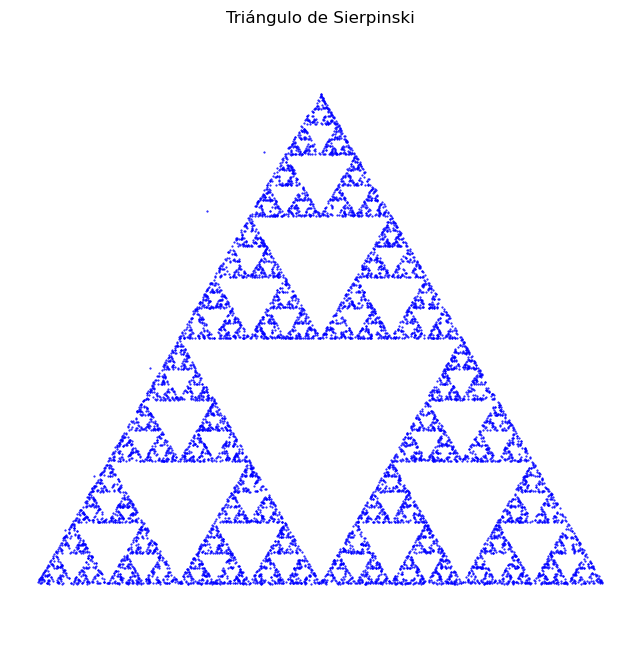

In [3]:
#Define una función llamada plot_sierpinski_triangle que recibe como parámetro n_points, el número de puntos que se dibujarán para formar el triángulo.
def plot_sierpinski_triangle(n_points):
    # Puntos iniciales del triángulo
    vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

    # Punto inicial aleatorio dentro del triángulo
    point = np.random.rand(2)

    # Generar el triángulo de Sierpinski
    plt.figure(figsize=(8, 8))
    for _ in range(n_points):
        # Seleccionar un vértice aleatorio
        vertex = vertices[np.random.randint(3)]

        # Calcular el punto medio entre el punto actual y el vértice seleccionado
        point = (point + vertex) / 2

        # Dibujar el punto en color azul
        plt.plot(point[0], point[1], 'b.', markersize=1)

    # Configuraciones adicionales
    plt.title('Triángulo de Sierpinski')
    plt.axis('equal')
    plt.axis('off')
    #plt.savefig("C:/Users/brend/OneDrive/Escritorio/sierpinski.png", dpi=300)
    plt.show()

# Definir el número de puntos a generar
n_points = 10000

# Generar y mostrar el Triángulo de Sierpinski en color azul
plot_sierpinski_triangle(n_points)

# Visualización de EEG

In [4]:
# Recorrer todos los archivos y mostrar su número de datos
for nombre, ruta in rutas_archivos:
    datos = pd.read_table(ruta, header=None)[0]
    print(f"{nombre}: {len(datos)} datos")

GH_M_O2: 136664 datos
MG_F_T4: 344376 datos
RL_F_T4: 460194 datos
RR_M_O2: 164954 datos


In [5]:
# Leer todos los datos del archivo
datos_uno = pd.read_table(ruta_archivo, header=None)[0]

# Imprimir número total de datos
print(f"Número total de datos en el archivo seleccionado ({ruta_archivo}): {len(datos_uno)}")


Número total de datos en el archivo seleccionado (C:\Users\brend\OneDrive\Escritorio\Curso Python\Datos EEG\Control\GH_M_O2.txt): 136664


In [6]:
# Crear un DataFrame vacío (crea una tabla vacía, sin columnas ni filas)
tabla = pd.DataFrame()

# Cargar cada archivo y agregar al DataFrame
for nombre, ruta in rutas_archivos:
    datos = pd.read_table(ruta, header=None)[0][:9000000]
    tabla[nombre] = datos
    

In [7]:
# Mostrar tabla
tabla

,GH_M_O2,MG_F_T4,RL_F_T4,RR_M_O2
0,6.9,2.4,-8.9,-13.1
1,5.5,2.4,-8.9,-13.9
2,5.9,2.5,-8.9,-12.7
3,3.4,2.5,-8.8,-13.8
4,4.8,2.7,-8.8,-12.1
...,...,...,...,...
136659,4.5,0.1,0.6,-12.5
136660,5.3,0.2,0.4,-13.5
136661,3.4,-0.1,0.4,-10.5
136662,5.0,-0.4,0.4,-14.3


In [8]:
# Leer archivo (solo la primera columna, hasta 9,000,000 datos)
GH = pd.read_table(ruta_archivo, header=None)[0][:9000000]

In [9]:
tabla1 = pd.DataFrame({'O2':GH})

In [10]:
tabla1

,O2
0,6.9
1,5.5
2,5.9
3,3.4
4,4.8
...,...
136659,4.5
136660,5.3
136661,3.4
136662,5.0


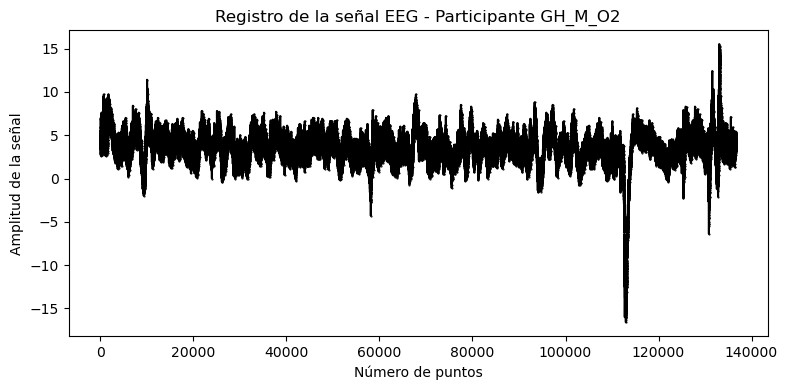

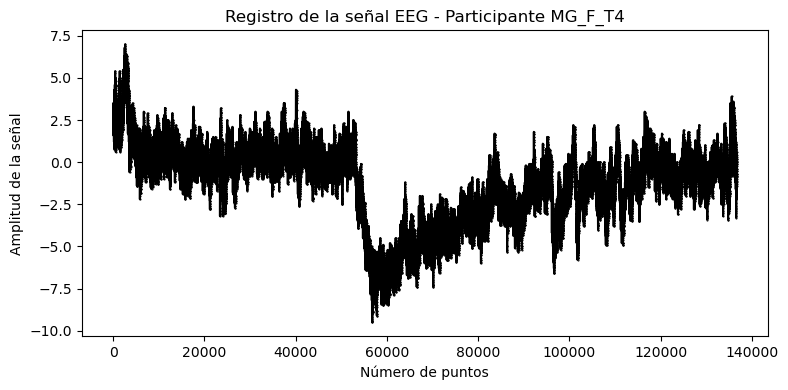

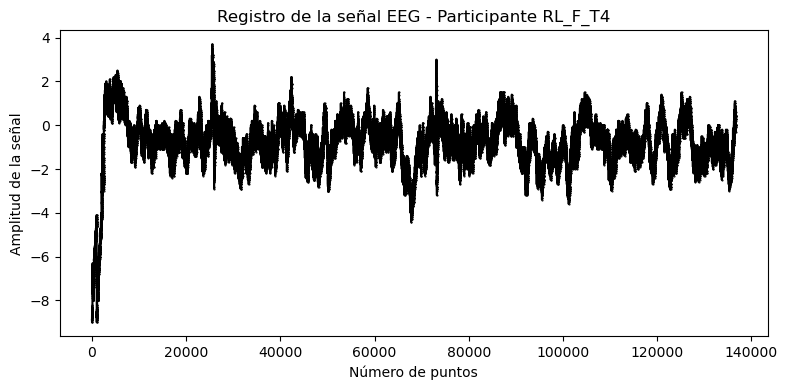

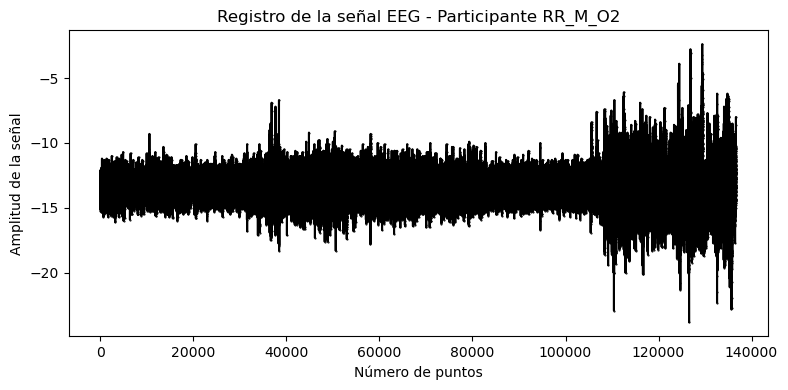

In [11]:
# Recorrer cada columna del DataFrame
for nombre in tabla.columns:
    plt.figure(figsize=(8, 4))
    #tabla.index: valores del eje X (los índices de la tabla, que representan los números de muestra)
    #tabla[nombre]: valores del eje Y (la señal EEG de ese participante)
    plt.plot(tabla.index, tabla[nombre], color='black', marker='.', markersize=1)
    plt.xlabel('Número de puntos')
    plt.ylabel('Amplitud de la señal')
    plt.title(f'Registro de la señal EEG - Participante {nombre}')
    #Ajusta automáticamente los márgenes de la figura.
    plt.tight_layout()
    plt.show()

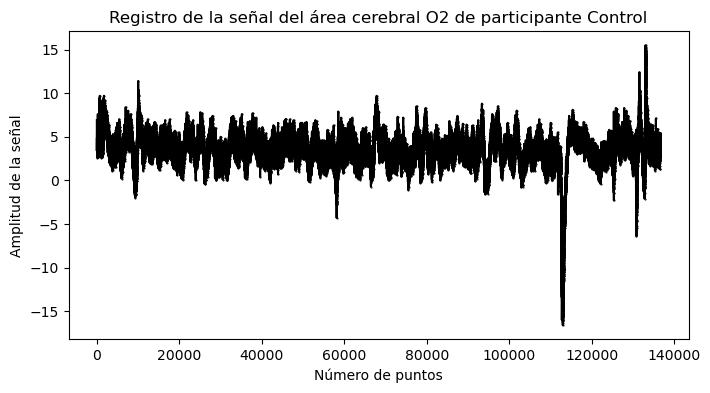

In [16]:
# Graficar señal
plt.figure(figsize=(8, 4))  # Tamaño de la figura (ancho, alto)
plt.plot(tabla1.index, tabla1.O2, color='black', marker='.', markersize=1) # Tamaño de los puntos
plt.xlabel('Número de puntos') # Etiqueta del eje x
plt.ylabel('Amplitud de la señal') # Etiqueta del eje y
plt.title('Registro de la señal del área cerebral O2 de participante Control') # Título del gráfico
#plt.savefig("C:/Users/brend/OneDrive/Escritorio/mi_grafica_O2.png", dpi=300)  # Guardar imagen con buena resolución en la ruta
plt.show()

# Fractal a partir de señal EEG

Procesando: GH_M_O2


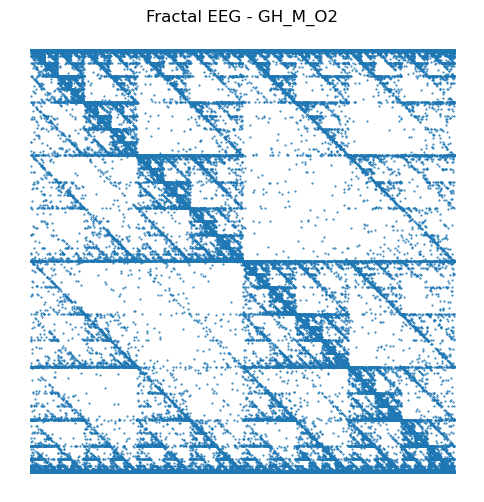

Procesando: MG_F_T4


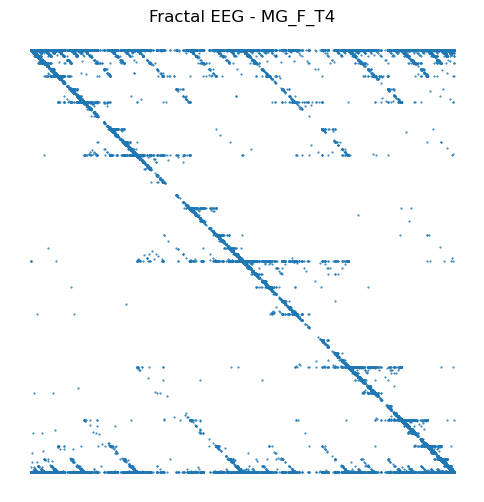

Procesando: RL_F_T4


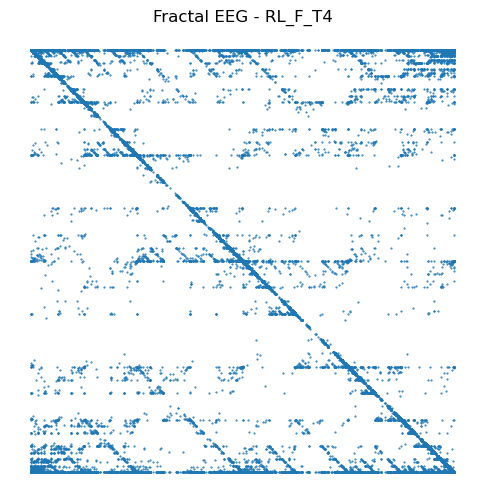

Procesando: RR_M_O2


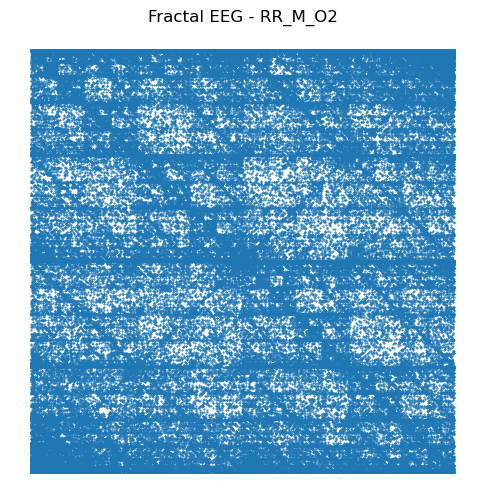

In [14]:
# Puntos de referencia para el fractal
p1 = [0, 0]
p2 = [1, 0]
p3 = [0, 1]
p4 = [1, 1]

# Recorrer cada archivo EEG
for nombre, ruta in rutas_archivos:
    print(f"Procesando: {nombre}")

    # Leer archivo (solo primera columna)
    data = pd.read_table(ruta, header=None)[0].values
    p = len(data)

    # Eje x: índice de muestras
    x = np.arange(p)

    # z = columna para etiquetas (clases)
    z = np.zeros((p,))

    # Combinar en matriz: [x, y, clase]
    Y = np.column_stack((x, data, z))

    # Reordenar por amplitud (columna 1)
    Y2 = Y[Y[:, 1].argsort()]

    t = p // 4  # Cantidad por clase

    # Asignar clases 1 a 4
    Y2[:t, 2] = 1
    Y2[t:2*t, 2] = 2
    Y2[2*t:3*t, 2] = 3
    Y2[3*t:, 2] = 4

    # Ordenar de nuevo por índice (columna 0)
    B1 = Y2[Y2[:, 0].argsort()]

    # Inicializar fractal
    fractal = np.zeros((p, 3))
    initial = np.array([0.5, 0.5])

    # Construir coordenadas fractales
    for f in range(p):
        clase = B1[f][2]
        if clase == 1:
            initial = np.mean([p1, initial], axis=0)
        elif clase == 2:
            initial = np.mean([p2, initial], axis=0)
        elif clase == 3:
            initial = np.mean([p3, initial], axis=0)
        elif clase == 4:
            initial = np.mean([p4, initial], axis=0)

        fractal[f, 0] = initial[0]
        fractal[f, 1] = initial[1]

    # Graficar fractal
    plt.figure(figsize=(6, 6))
    plt.plot(fractal[:, 0], fractal[:, 1], linestyle='None', marker='.', markersize=1)
    plt.title(f'Fractal EEG - {nombre}')
    plt.axis('off')
    plt.axis('equal')

    # Guardar la figura
    #ruta_guardado = f"C:/Users/brend/OneDrive/Escritorio/Fractales/{nombre}_fractal.png"
    #os.makedirs(os.path.dirname(ruta_guardado), exist_ok=True)
    #plt.savefig(ruta_guardado, dpi=300)
    plt.show()